In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
file_path = "phillies.csv"
df = pd.read_csv(file_path)

In [ ]:
df['Name'].value_counts()

,count
Name,
"Betts, Mookie",11
"Machado, Manny",11
"Goldschmidt, Paul",11
"Santana, Carlos",10
"Altuve, Jose",10
...,...
"Durbin, Caleb",1
"Holliday, Jackson",1
"Meidroth, Chase",1


In [ ]:
df.columns

Index(['Name', 'player_id', 'year', 'Age', 'pa', 'k_percent', 'bb_percent',
       'batting_avg', 'slg_percent', 'on_base_percent', 'on_base_plus_slg',
       'babip', 'xba', 'xslg', 'woba', 'xwoba', 'xobp', 'xiso', 'xwobacon',
       'xbacon', 'xslgdiff', 'wobadiff', 'avg_swing_speed', 'fast_swing_rate',
       'exit_velocity_avg', 'sweet_spot_percent', 'barrel_batted_rate',
       'solidcontact_percent', 'flareburner_percent', 'poorlyunder_percent',
       'poorlytopped_percent', 'poorlyweak_percent', 'hard_hit_percent',
       'avg_best_speed', 'avg_hyper_speed', 'whiff_percent', 'swing_percent',
       'groundballs_percent', 'n_outs_above_average'],
      dtype='object')

In [ ]:
features = [
    "k_percent", "bb_percent", "swing_percent", "whiff_percent",
    "barrel_batted_rate", "hard_hit_percent", "sweet_spot_percent", "solidcontact_percent",
    "xobp", "xba", "xiso", "wobadiff", "poorlyweak_percent",
    "avg_best_speed", "avg_hyper_speed",
    "woba", "babip", "Age", "flareburner_percent", "groundballs_percent"
]

targets = ["batting_avg", "on_base_percent", "slg_percent",
           "on_base_plus_slg", "xwoba", "xslg"]

In [ ]:
df = df.dropna(subset=features)
X = df[features]
y = df[targets].fillna(df[targets].mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

base_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model = MultiOutputRegressor(base_model)
model.fit(X_scaled, y)
print("✅ Model trained successfully with Gradient Boosting.")

✅ Model trained successfully with Gradient Boosting.


In [ ]:
# 3. Compute Player Trend
def get_player_trend(df, player_id, stat_cols, window=3):
    player_data = df[df["player_id"] == player_id].sort_values("year")
    if len(player_data) < 2:
        return 0.0

    player_data = player_data.tail(window)
    slopes = []

    for stat in stat_cols:
        if stat in player_data.columns and player_data[stat].nunique() > 1:
            x = np.arange(len(player_data))
            y = player_data[stat].values
            slope = np.polyfit(x, y, 1)[0] / np.mean(y)
            slopes.append(slope)

    return np.mean(slopes) if slopes else 0.0


In [ ]:

# 4. Monte Carlo Projection with Age Decline
def monte_carlo_player(player_features, player_id, df,
                       n_sim=1000, years=5,
                       trend_std=0.02, noise_std=0.05):
    trend_stats = [
        "woba", "xwoba", "hard_hit_percent", "sweet_spot_percent",
        "barrel_batted_rate", "solidcontact_percent",
        "xobp", "xba", "groundballs_percent"
    ]

    trend_mean = get_player_trend(df, player_id, trend_stats)

    # Age-based decline adjustment
    player_age = df.loc[df["player_id"] == player_id, "Age"].max()
    if player_age > 30:
        age_penalty = -0.01 * (player_age - 34)  # -1% per year after 30-32
        trend_mean += age_penalty
        if trend_mean > 0:
            trend_mean = min(trend_mean, 0.005)  # cap unrealistic improvement

    # Model prediction baseline
    scaled_features = scaler.transform(player_features.values.reshape(1, -1))
    base_prediction = model.predict(scaled_features)[0]

    simulations = np.zeros((n_sim, years, len(targets)))

    for sim in range(n_sim):
        yearly_trend = np.random.normal(trend_mean, trend_std)
        random_shocks = np.random.normal(1, noise_std, (years, len(targets)))
        for yr in range(years):
            age_decline_factor = 1 - 0.02 * max(0, (player_age + yr) - 32)
            trend_factor = ((1 + yearly_trend) ** yr) * (age_decline_factor ** yr)
            simulations[sim, yr, :] = base_prediction * trend_factor * random_shocks[yr]

    mean_projection = simulations.mean(axis=0)
    lower_bound = np.percentile(simulations, 0.5, axis=0)
    upper_bound = np.percentile(simulations, 99.5, axis=0)

    return mean_projection, lower_bound, upper_bound, trend_mean

In [ ]:
# 5. Generate Projections for Phillies
target_players = ["Harper", "Schwarber", "Realmuto", "Bohm", "Turner"]
results = []

for lname in target_players:
    player_rows = df[df["Name"].str.contains(lname, case=False, na=False)]
    if player_rows.empty:
        print(f"⚠️ No player found for {lname}")
        continue

    player_row = player_rows.sort_values("year").iloc[-1]
    player_id = player_row["player_id"]
    player_features = player_row[features]

    means, lows, highs, trend = monte_carlo_player(
        player_features=player_features,
        player_id=player_id,
        df=df,
        n_sim=2000,
        years=5
    )

    for i, year in enumerate(range(2026, 2031)):
        row = {"player": lname, "year": year}
        for j, stat in enumerate(targets):
            row[f"{stat}_mean"] = means[i, j]
            row[f"{stat}_low"] = lows[i, j]
            row[f"{stat}_high"] = highs[i, j]
        row["trend_mean"] = trend
        results.append(row)

    print(f"✅ {lname}: inferred trend = {trend:+.2%} per year")

proj_df = pd.DataFrame(results)
proj_df.to_csv("phillies_2026_2030_montecarlo.csv", index=False)
print("✅ Saved → phillies_2026_2030_montecarlo.csv")

✅ Harper: inferred trend = +0.08% per year
✅ Schwarber: inferred trend = +0.50% per year


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


✅ Realmuto: inferred trend = -3.77% per year
✅ Bohm: inferred trend = -0.01% per year
✅ Turner: inferred trend = +0.18% per year
✅ Saved → phillies_2026_2030_montecarlo.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


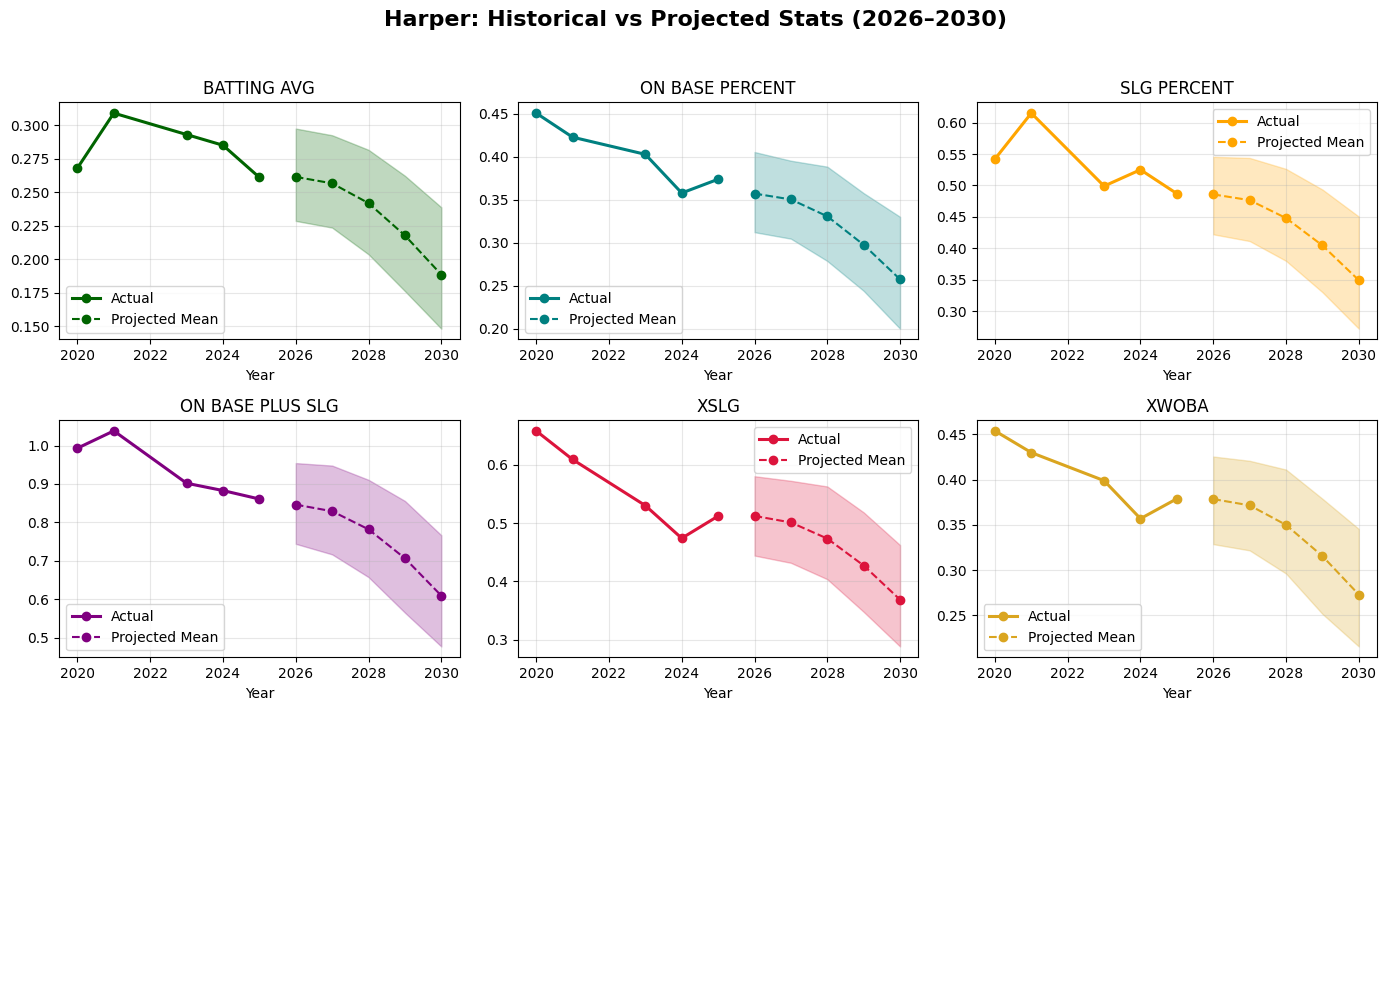

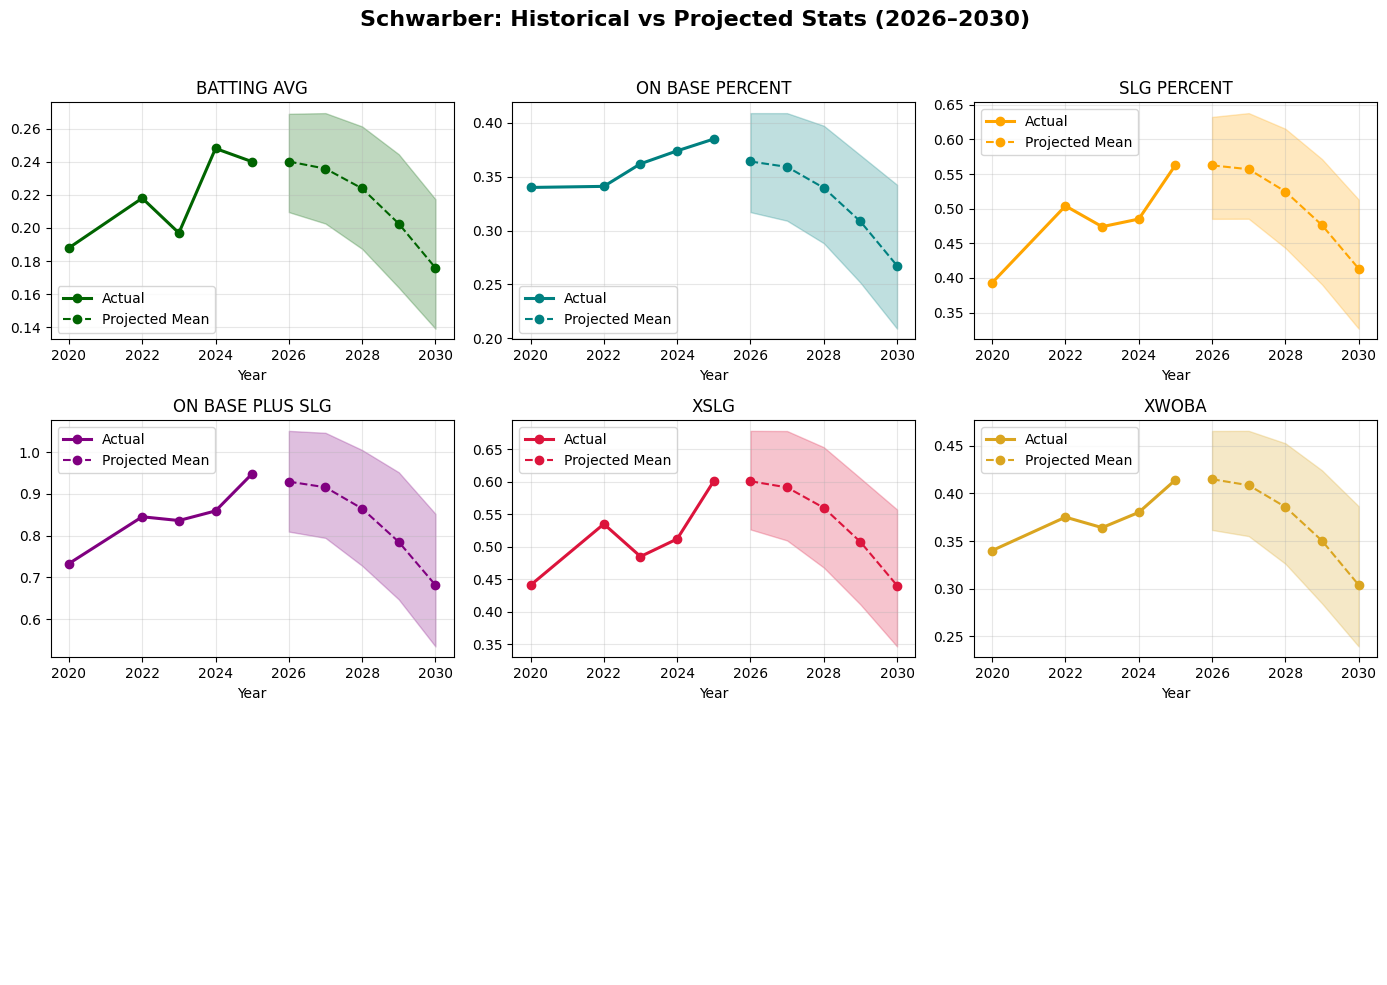

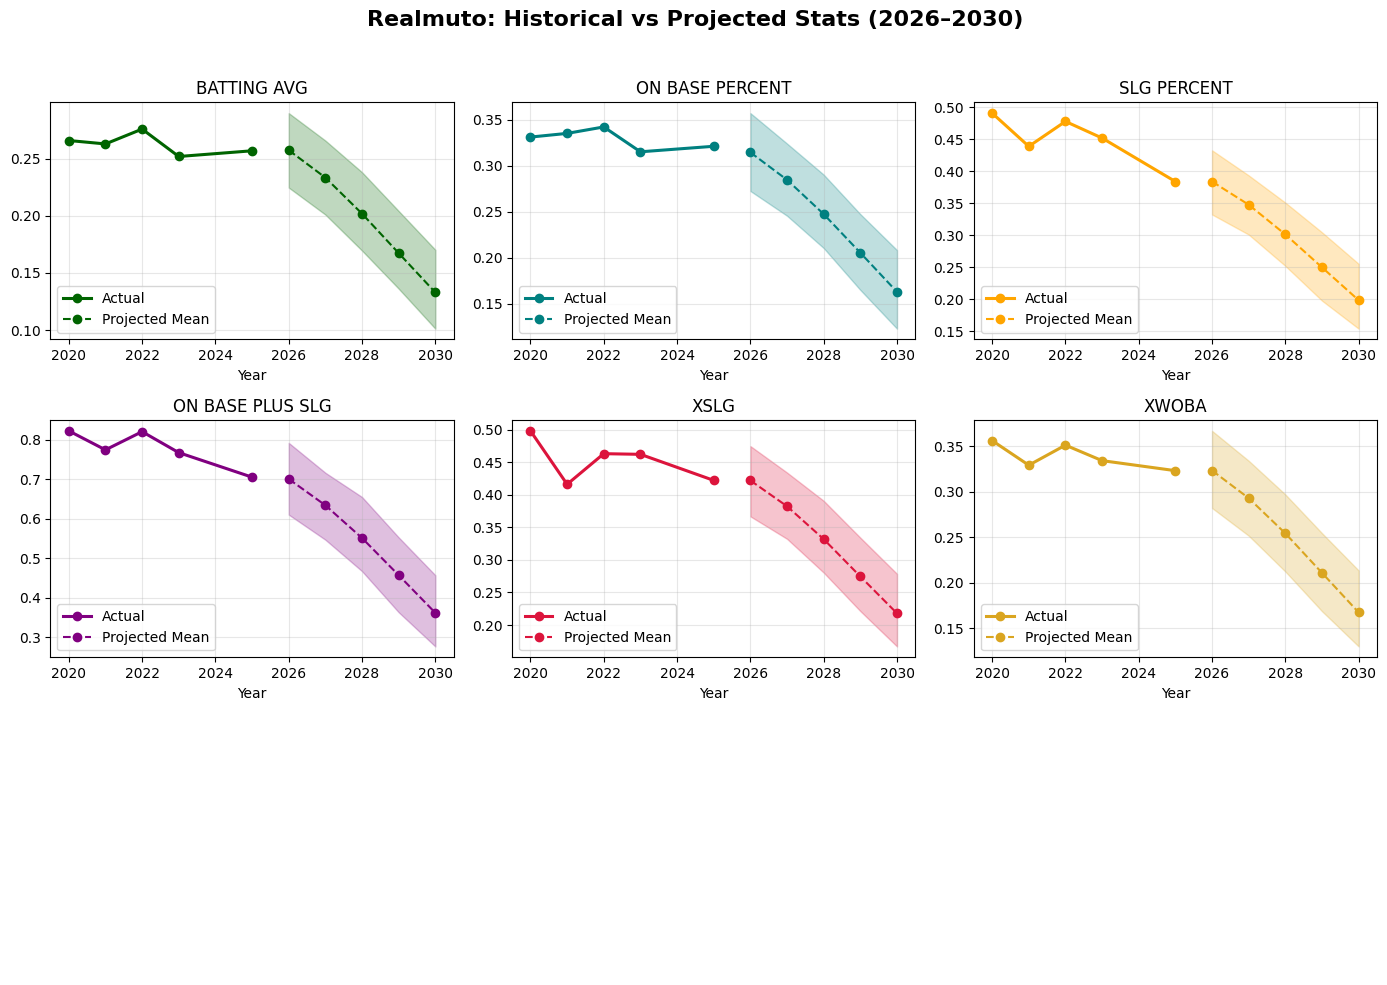

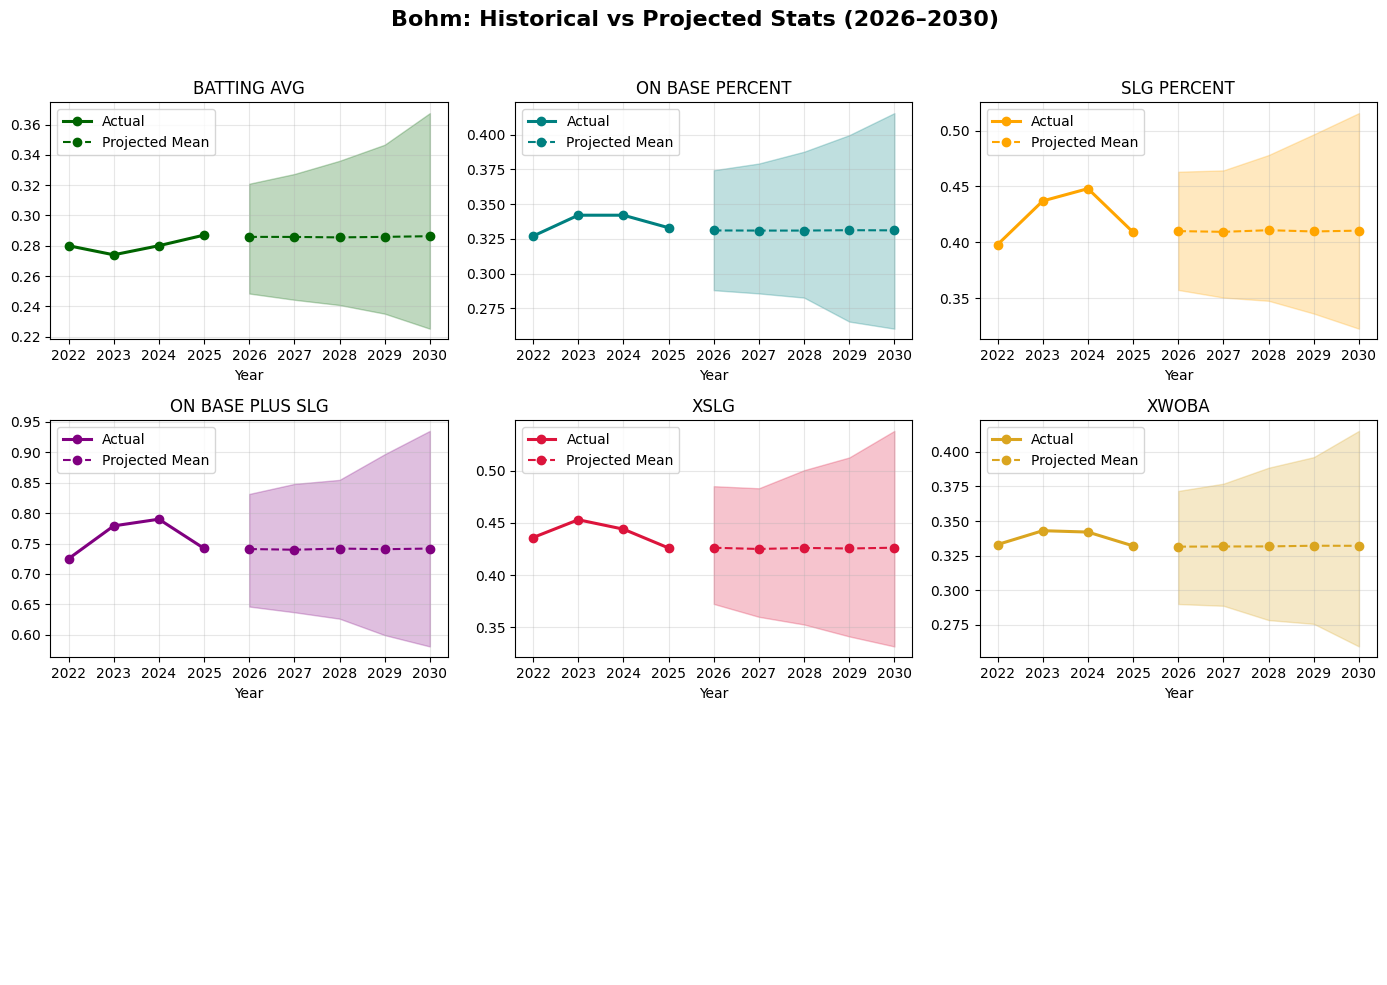

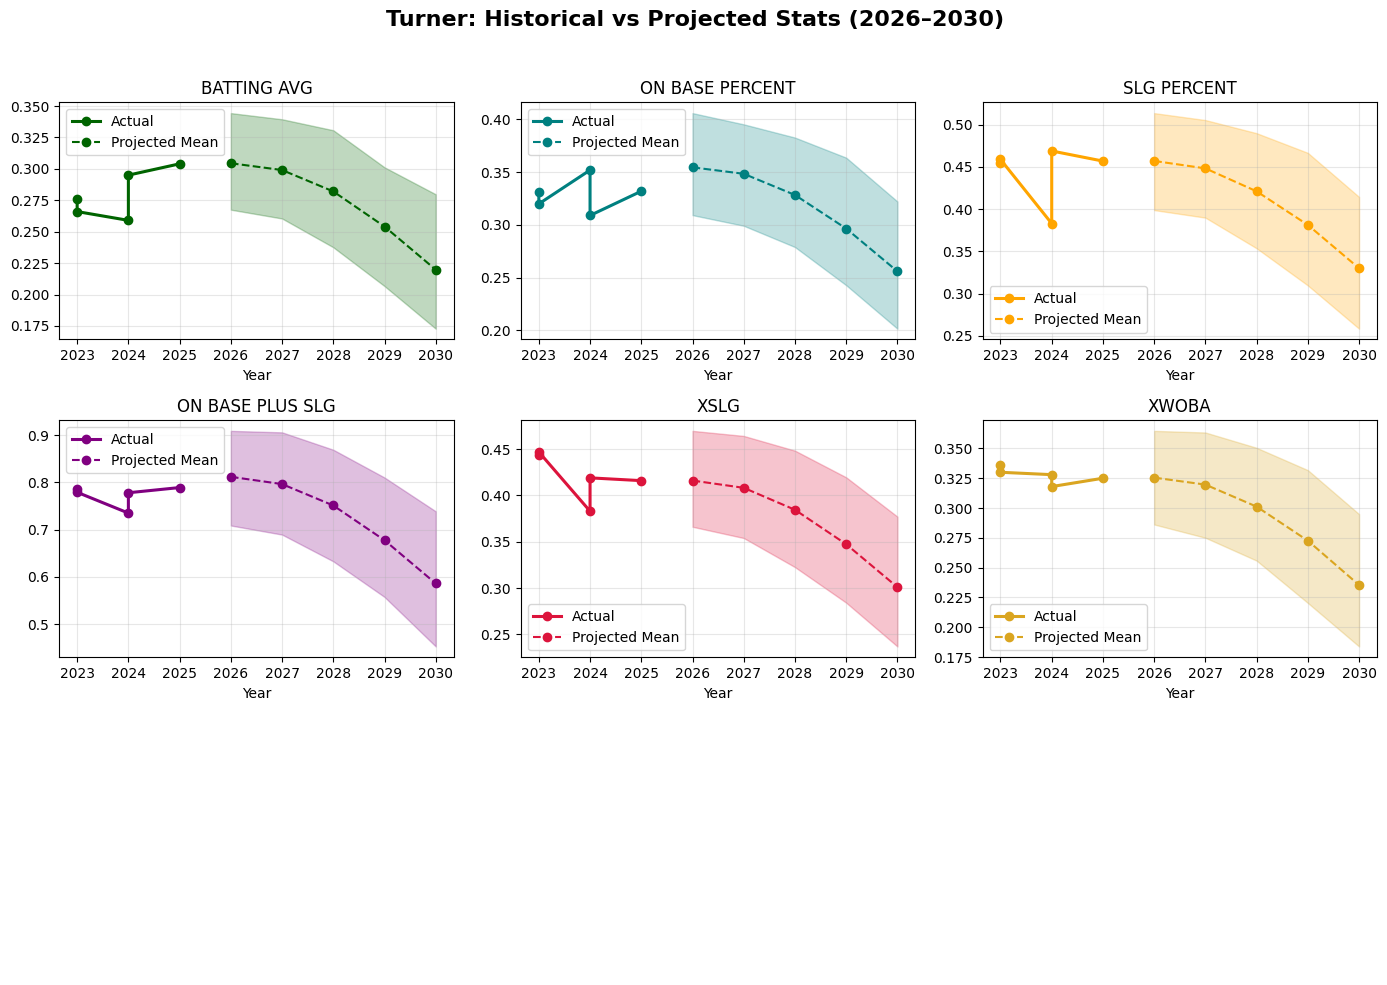

In [ ]:
# 6. Plot Historical vs Projected Stats
stats_to_plot = ["batting_avg", "on_base_percent", "slg_percent",
                 "on_base_plus_slg", "xslg", "xwoba"]

colors = {
    "batting_avg": "darkgreen",
    "on_base_percent": "teal",
    "slg_percent": "orange",
    "on_base_plus_slg": "purple",
    "xslg": "crimson",
    "xwoba": "goldenrod"
}

for player in target_players:
    sub_proj = proj_df[proj_df["player"] == player]
    hist = df[df["Name"].str.contains(player, case=False, na=False)].copy()
    if sub_proj.empty or hist.empty:
        continue

    hist = hist.sort_values("year").tail(5)
    fig, axes = plt.subplots(3, 3, figsize=(14, 10))
    axes = axes.flatten()
    fig.suptitle(f"{player}: Historical vs Projected Stats (2026–2030)",
                 fontsize=16, fontweight="bold")

    for i, stat in enumerate(stats_to_plot):
        ax = axes[i]
        hist_col = stat
        if stat == "on_base_percent":
            hist_col = "xobp" if "xobp" in hist.columns else "xwoba"
        elif stat == "on_base_plus_slg":
            hist["on_base_plus_slg"] = hist.get("xobp", hist["xwoba"]) + hist["slg_percent"]
            hist_col = "on_base_plus_slg"

        if hist_col in hist.columns:
            ax.plot(hist["year"], hist[hist_col], marker="o", color=colors[stat],
                    label="Actual", linewidth=2.2)
        ax.plot(sub_proj["year"], sub_proj[f"{stat}_mean"], marker="o",
                linestyle="--", color=colors[stat], label="Projected Mean")
        ax.fill_between(sub_proj["year"],
                        sub_proj[f"{stat}_low"], sub_proj[f"{stat}_high"],
                        alpha=0.25, color=colors[stat])
        ax.set_title(stat.replace("_", " ").upper())
        ax.set_xlabel("Year")
        ax.grid(True, alpha=0.3)
        ax.legend()

    for j in range(len(stats_to_plot), len(axes)):
        axes[j].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
# 7. MLB Baselines and Percentile Rankings
mlb_baselines = (
    df.groupby("year")[["woba", "xwoba", "slg_percent", "batting_avg", "xslg"]]
    .agg(["mean", "std", "min", "max"])
)
print(mlb_baselines.tail(3))

league_means = df.groupby("year").mean(numeric_only=True)
league_stds = df.groupby("year").std(numeric_only=True)

comparison_stats = ["batting_avg", "on_base_percent", "slg_percent",
                    "on_base_plus_slg", "xslg", "xwoba"]

percentile_rows = []

for _, row in proj_df.iterrows():
    year = row["year"]
    for stat in comparison_stats:
        if stat not in league_means.columns:
            continue
        league_mean = league_means.loc[year, stat] if year in league_means.index
        else league_means.iloc[-1][stat]
        league_std = league_stds.loc[year, stat] if year in league_stds.index
        else league_stds.iloc[-1][stat]
        z = (row[f"{stat}_mean"] - league_mean) / league_std if league_std > 0 else 0
        percentile = norm.cdf(z) * 100
        percentile_rows.append({
            "player": row["player"],
            "year": year,
            "stat": stat,
            "value": row[f"{stat}_mean"],
            "percentile_rank": percentile
        })

percentile_df = pd.DataFrame(percentile_rows)
percentile_df.to_csv("phillies_vs_mlb_percentiles_2026_2030.csv", index=False)
print("✅ Saved → phillies_vs_mlb_percentiles_2026_2030.csv")


          woba                             xwoba                          \
          mean       std    min    max      mean       std    min    max   
year                                                                       
2023  0.335463  0.030934  0.260  0.433  0.336291  0.031970  0.272  0.460   
2024  0.330783  0.032852  0.270  0.476  0.331364  0.034675  0.261  0.479   
2025  0.331431  0.029698  0.263  0.463  0.342021  0.031878  0.278  0.476   

     slg_percent                         batting_avg                          \
            mean       std    min    max        mean       std    min    max   
year                                                                           
2023    0.444679  0.060222  0.296  0.654    0.261724  0.025337  0.197  0.354   
2024    0.435922  0.061989  0.331  0.701    0.258147  0.025159  0.196  0.332   
2025    0.436653  0.060028  0.306  0.688    0.258562  0.022604  0.200  0.331   

          xslg                          
          mean       

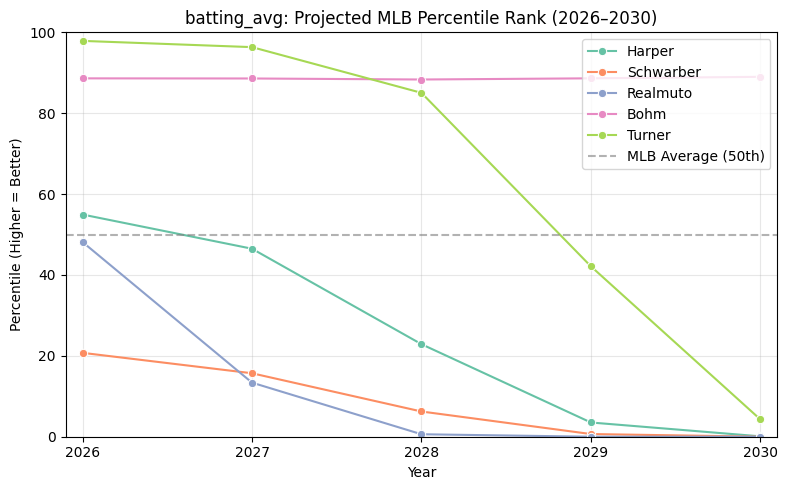

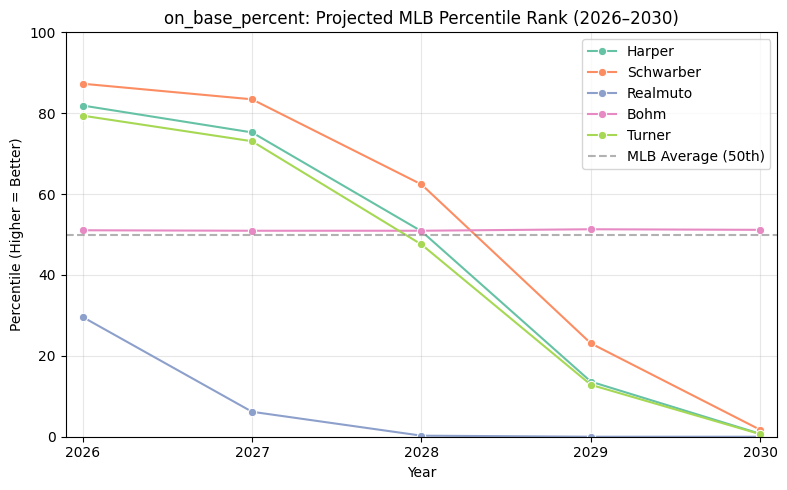

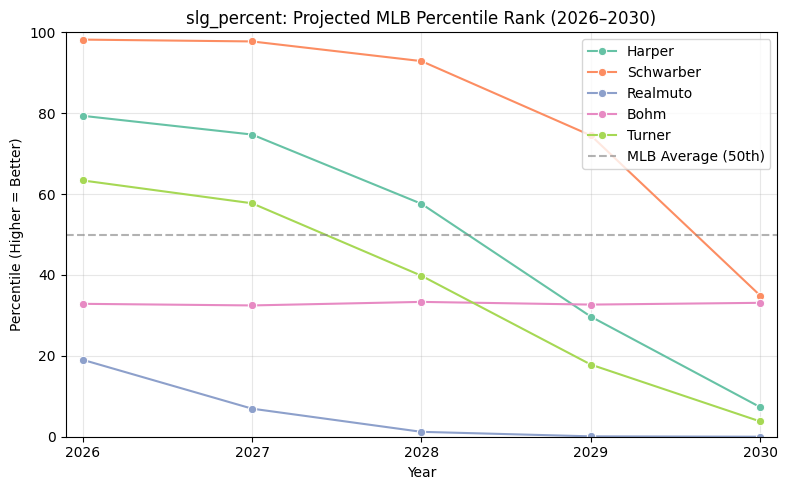

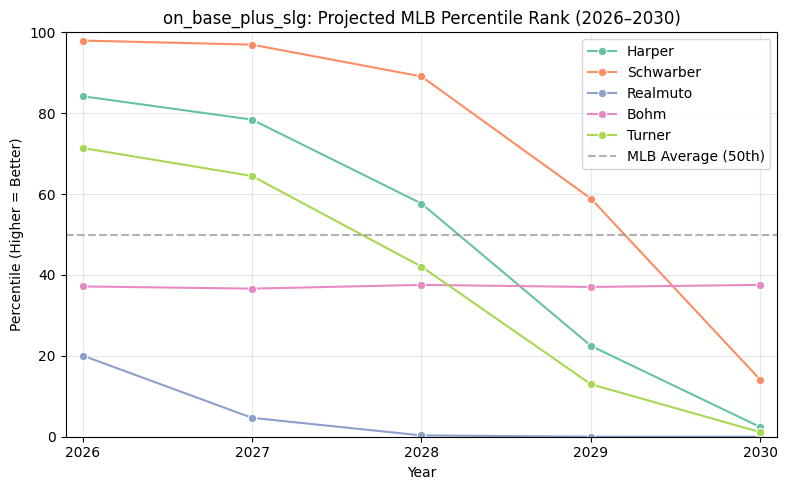

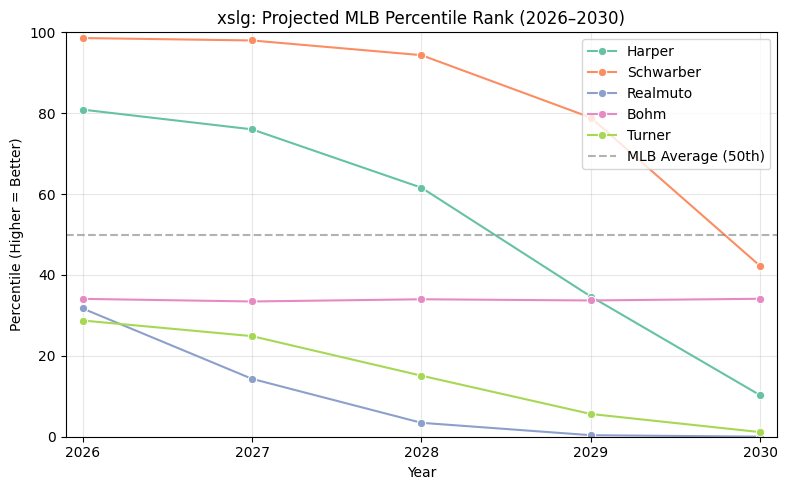

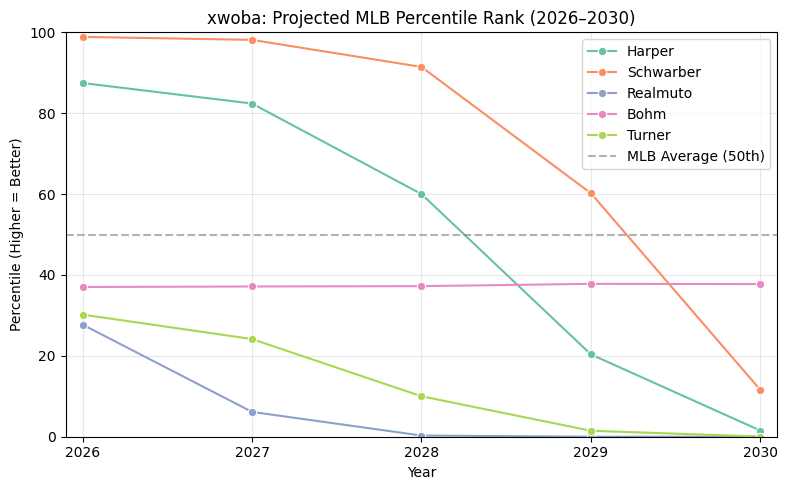

In [ ]:
# 8. Visualize Percentile Rankings
for stat in comparison_stats:
    plt.figure(figsize=(8, 5))
    sub = percentile_df[percentile_df["stat"] == stat]

    #percentile trends
    sns.lineplot(
        data=sub,
        x="year",
        y="percentile_rank",
        hue="player",
        marker="o",
        palette="Set2"
    )

    #MLB average line
    plt.axhline(50, color="gray", linestyle="--", alpha=0.6, label="MLB Average (50th)")

    plt.title(f"{stat}: Projected MLB Percentile Rank (2026–2030)")
    plt.ylabel("Percentile (Higher = Better)")
    plt.xlabel("Year")
    plt.ylim(0, 100)
    plt.legend()
    plt.grid(True, alpha=0.3)


    years = sorted(sub["year"].unique())
    plt.xticks(years)
    plt.xlim(min(years) - 0.1, max(years) + 0.1)
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))

    plt.tight_layout()
    plt.show()
